# Лабораторная работа 4
## Вариант 10

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np


FLOW - массовый расход газа (кг/с).

PIN - давление на всасывании (МПа).

POUT - давление на нагнетании (МПа).

TIN - температура на всасывании (°C).

TOUT - температура на нагнетании (°C).

RPM - частота вращения ротора (об/мин).

VIB - уровень вибрации (мм/с).

AMB - температура окружающего воздуха (°C).

MW - молекулярная масса газовой смеси (г/моль).

COMP - степень сжатия (отношение POUT / PIN).

POWER - Целевая переменная : Потребляемая мощность электродвигателя компрессора (кВт).

10     FLOW (Расход)	POWER (Мощность)

# Часть 1

## 1. Загрузите датасет параметров работы центробежного компрессора

In [3]:
df = pd.read_csv('compressor_dataset.csv')
df.head(7)

,FLOW,PIN,POUT,TIN,TOUT,RPM,VIB,AMB,MW,COMP,POWER,STATE
0,87.45,2.37,4.49,30.2,115.8,8575.0,2.26,11.5,17.02,1.893,6320.0,0
1,145.07,3.08,5.77,33.9,114.4,10342.0,2.45,24.3,15.59,1.870,8759.2,0
2,123.20,3.75,10.71,17.5,154.9,10673.0,1.42,21.8,17.17,2.859,9331.1,0
3,109.87,3.46,6.49,28.7,118.3,9470.0,2.33,-11.5,18.23,1.874,7230.3,0
4,65.60,3.61,6.89,27.2,109.3,7732.0,0.86,-11.8,17.93,1.908,6197.6,0
5,65.60,3.32,8.76,35.0,147.1,8582.0,2.10,-5.3,17.84,2.639,7123.6,1
6,55.81,3.38,7.36,37.2,133.1,7443.0,1.41,-0.1,17.28,2.175,6144.2,0


## 2. Вычислите выборочные оценки среднего значения и среднеквадратического отклонения каждого массива

In [4]:
mean_flow = df['FLOW'].mean()
mean_power = df['POWER'].mean()
std_flow = df['FLOW'].std()
std_power = df['POWER'].std()
print(f"Среднее значение потока: {mean_flow}")
print(f"Среднее значение мощности: {mean_power}")
print(f"Стандартное отклонение потока: {std_flow}")
print(f"Стандартное отклонение мощности: {std_power}")


Среднее значение потока: 99.02570999999999
Среднее значение мощности: 7571.1271
Стандартное отклонение потока: 29.213774934811862
Стандартное отклонение мощности: 1212.8811934501314


## 3. Вычислите коэффициент корреляции между каждым из выбранных массивов (А1, А2) и целевой переменной (поле STATE).

In [5]:
correl_flow_state = df['FLOW'].corr(df['STATE'])
correl_power_state = df['POWER'].corr(df['STATE'])
print(f"Корреляция между потоком и состоянием: {correl_flow_state}")
print(f"Корреляция между мощностью и состоянием: {correl_power_state}")

Корреляция между потоком и состоянием: -0.39501823551672244
Корреляция между мощностью и состоянием: -0.17348403016484368


## 4. Постройте диаграммы hist (гистограмма) и boxplot по выбранным признакам А1 и А2 
(отдельно по каждому признаку) со сгруппировкой по двум классам данных (0 - Норма, 1 - Помпаж). \
Проведите интерпретацию результатов: отличаются ли визуально медианы и разбросы этих признаков для разных состояний компрессора?

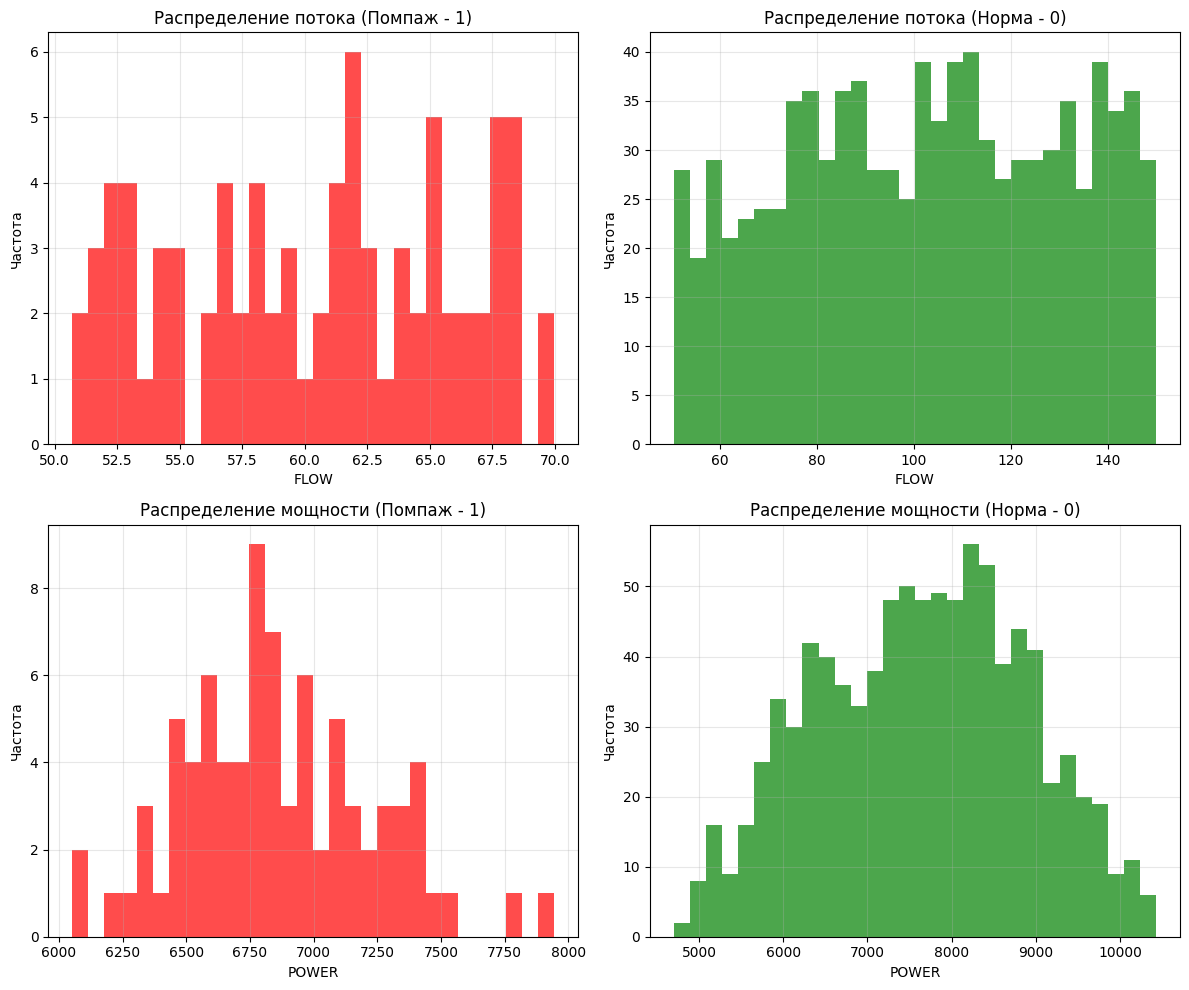

In [6]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.hist(df[df['STATE'] == 1]['FLOW'], color='red', alpha=0.7, bins=30)
plt.title('Распределение потока (Помпаж - 1)')
plt.xlabel('FLOW')
plt.ylabel('Частота')
plt.grid(alpha=0.3)

plt.subplot(2, 2, 2)
plt.hist(df[df['STATE'] == 0]['FLOW'], color='green', alpha=0.7, bins=30)
plt.title('Распределение потока (Норма - 0)')
plt.xlabel('FLOW')
plt.ylabel('Частота')
plt.grid(alpha=0.3)

plt.subplot(2, 2, 3)
plt.hist(df[df['STATE'] == 1]['POWER'], color='red', alpha=0.7, bins=30)
plt.title('Распределение мощности (Помпаж - 1)')
plt.xlabel('POWER')
plt.ylabel('Частота')
plt.grid(alpha=0.3)

plt.subplot(2, 2, 4)
plt.hist(df[df['STATE'] == 0]['POWER'], color='green', alpha=0.7, bins=30)
plt.title('Распределение мощности (Норма - 0)')
plt.xlabel('POWER')
plt.ylabel('Частота')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### для этих двух признаков есть специфика - они ограничены в значениях:
- flow от 50 до 70 с помпажом, при общей разнице значений от 50 до 150
- power от 6000 до 8000 при общей разнице от 4500 до 10500
#### в таком случае среднее значение будет сильно отличаться

## 5. Отобразите на диаграмме рассеяния (scatter) объекты
, содержащие выбранные 2 признака (признак А1 - ось X, признак A2 - ось Y).\
 Отобразите объекты, относящиеся к разным классам (STATE),\
 разным цветом. Сделайте вывод о линейной разделимости классов.

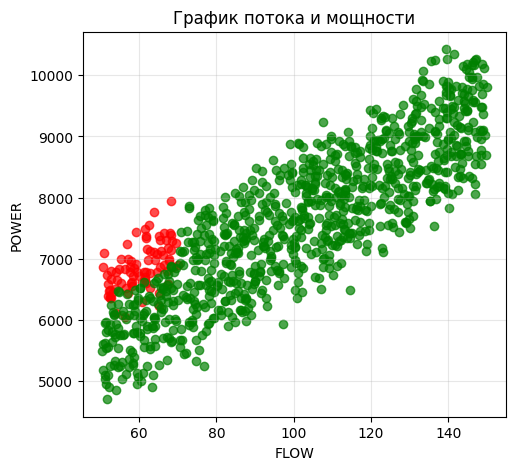

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df[df['STATE']==1]['FLOW'], df[df['STATE']==1]['POWER'], color='red', alpha=0.7)
plt.scatter(df[df['STATE']==0]['FLOW'], df[df['STATE']==0]['POWER'], color='green', alpha=0.7)
plt.title('График потока и мощности')
plt.xlabel('FLOW')
plt.ylabel('POWER')
plt.grid(alpha=0.3)

#### Графики не разделимы линейно, но есть четкое разделение между группами(правда местами они пересекаются)

## 6. Сформируйте из наборов данных обучающую и тестовую выборки (80% / 20%).

In [8]:
x_train, x_test, y_train, y_test  = train_test_split(df[['FLOW', 'POWER']], df['STATE'], test_size=0.2, random_state=42)

## 7.
### 7.1. Постройте модель машинного обучения вида линейной дискриминантной функции (LinearDiscriminantAnalysis из sklearn.discriminant_analysis).



In [9]:
clf = LinearDiscriminantAnalysis()
clf.fit(x_train, y_train)

LinearDiscriminantAnalysis()

### 7.2. По тестовой выборке оцените качество классификации: confusion_matrix, accuracy, precision, recall, f1_score.

In [10]:
y_test_predict = clf.predict(x_test)
y_train_predict = clf.predict(x_train)
accuracy = accuracy_score(y_test, y_test_predict)
confusion = confusion_matrix(y_test, y_test_predict)
precision = precision_score(y_test, y_test_predict)
recall = recall_score(y_test, y_test_predict)
f1 = f1_score(y_test, y_test_predict)
print(f"Точность модели LDA: {accuracy:.4f}")
print(f"Полнота модели LDA: {recall:.4f}")
print(f"Точность предсказания модели LDA: {precision:.4f}")
print(f"F1-мера модели LDA: {f1:.4f}")
print("Матрица ошибок модели LDA:")
print(*confusion, sep="\n")


Точность модели LDA: 0.9250
Полнота модели LDA: 0.1765
Точность предсказания модели LDA: 0.7500
F1-мера модели LDA: 0.2857
Матрица ошибок модели LDA:
[182   1]
[14  3]


очень много ложноотрицательных значений, но при этом высокая точность \
оценить точность предсказывания положительных значений сложно, всего 4 таких значения, но precision 75%, относительно неплохо


### 7.3. Постройте график, на котором представьте результаты работы модели: разными цветами разделите точки по предсказанным классам, а разной формой маркера (или интенсивностью цвета) пометьте тестовую и обучающую выборки. По возможности отобразите разделяющую прямую.

In [11]:
x_min, x_max = x_train['FLOW'].min() - 1, x_train['FLOW'].max() + 1
y_min, y_max = x_train['POWER'].min() - 1, x_train['POWER'].max() + 1

w0, w1 = clf.coef_[0]
b = clf.intercept_[0]
x_line = np.array([x_min, x_max])
y_line = -(w0 * x_line + b) / w1


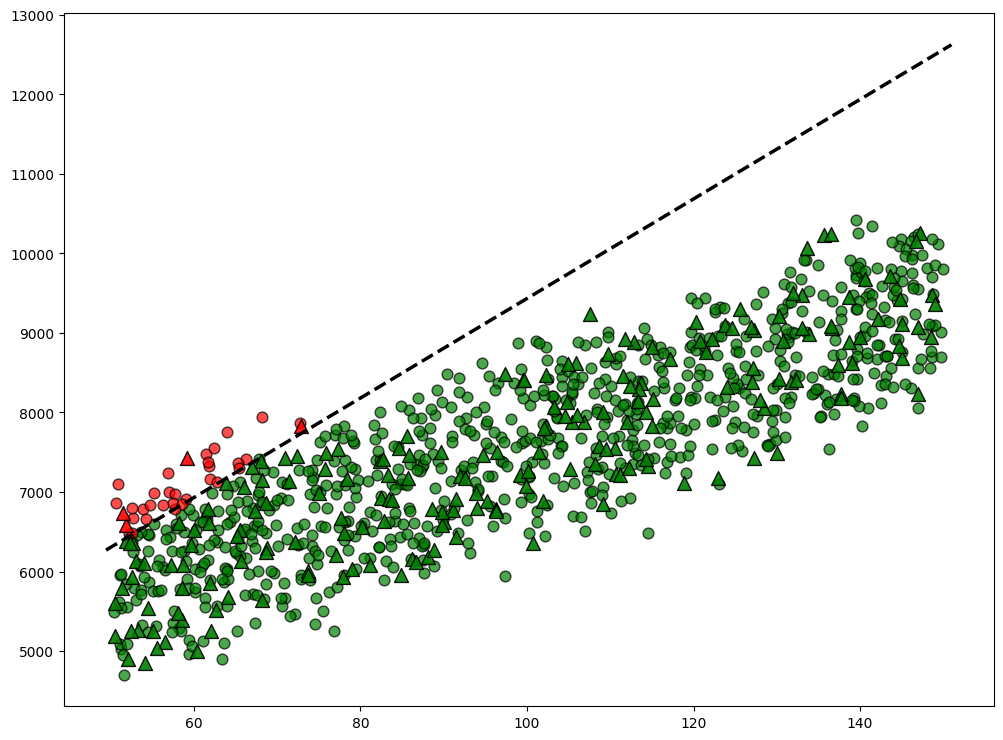

In [12]:
fig, ax = plt.subplots(figsize=(12, 9))

ax.scatter(x_train[y_train_predict == 0]['FLOW'], x_train[y_train_predict == 0]['POWER'],
           c='green', marker='o', edgecolors='black', s=60, alpha=0.7)
ax.scatter(x_train[y_train_predict == 1]['FLOW'], x_train[y_train_predict == 1]['POWER'],
           c='red', marker='o', edgecolors='black', s=60, alpha=0.7)

ax.scatter(x_test[y_test_predict == 0]['FLOW'], x_test[y_test_predict == 0]['POWER'],
           c='green', marker='^', edgecolors='black', s=100, alpha=0.9)
ax.scatter(x_test[y_test_predict == 1]['FLOW'], x_test[y_test_predict == 1]['POWER'],
           c='red', marker='^', edgecolors='black', s=100, alpha=0.9)
ax.plot(x_line, y_line, 'k--', linewidth=2.5, label='Разделяющая граница')

## 8.
### 8.1. Постройте модель машинного обучения вида k-ближайших соседей (KNeighborsClassifier из sklearn.neighbors). Подберите оптимальное количество соседей.

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

### 8.2. По тестовой выборке оцените качество классификации теми же метриками (матрица ошибок, точность, полнота и др.).

In [14]:
y_test_predict = knn.predict(x_test)
y_train_predict = knn.predict(x_train)
accuracy = accuracy_score(y_test, y_test_predict)
confusion = confusion_matrix(y_test, y_test_predict)
precision = precision_score(y_test, y_test_predict)
recall = recall_score(y_test, y_test_predict)
f1 = f1_score(y_test, y_test_predict)
print(f"Точность модели knn: {accuracy:.4f}")
print(f"Полнота модели knn: {recall:.4f}")
print(f"Точность предсказания модели knn: {precision:.4f}")
print(f"F1-мера модели knn: {f1:.4f}")
print("Матрица ошибок модели knn:")
print(*confusion, sep="\n")

Точность модели knn: 0.9450
Полнота модели knn: 0.3529
Точность предсказания модели knn: 1.0000
F1-мера модели knn: 0.5217
Матрица ошибок модели knn:
[183   0]
[11  6]


### 8.3. Постройте график результатов классификации для метода KNN.

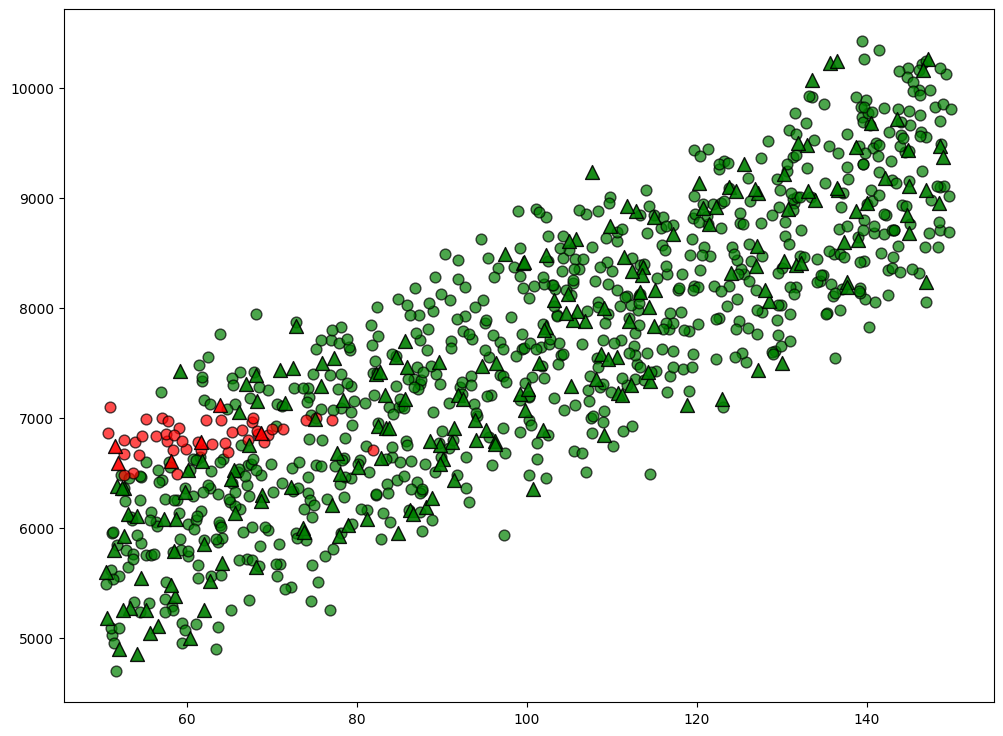

In [15]:
fig, ax = plt.subplots(figsize=(12, 9))

ax.scatter(x_train[y_train_predict == 0]['FLOW'], x_train[y_train_predict == 0]['POWER'],
           c='green', marker='o', edgecolors='black', s=60, alpha=0.7)
ax.scatter(x_train[y_train_predict == 1]['FLOW'], x_train[y_train_predict == 1]['POWER'],
           c='red', marker='o', edgecolors='black', s=60, alpha=0.7)

ax.scatter(x_test[y_test_predict == 0]['FLOW'], x_test[y_test_predict == 0]['POWER'],
           c='green', marker='^', edgecolors='black', s=100, alpha=0.9)
ax.scatter(x_test[y_test_predict == 1]['FLOW'], x_test[y_test_predict == 1]['POWER'],
           c='red', marker='^', edgecolors='black', s=100, alpha=0.9)

## 9.Представьте в виде таблицы сравнительную характеристику результатов работы двух методов на ваших двух признаках. Какой алгоритм справился лучше и почему?
|Метрика\Метод| LDA | kNN|
|-|-|-|
|Accuracy|0.925|0.945|
|precision|0.75|1|
|recall|0.1765|0.3529|
|f1|0.2857|0.5217|

Все метрики выше у метода поиска к ближайших соседей

# Часть 2
Работа со всеми признаками

Повторите задания 6-9, используя для обучения моделей все доступные предиктивные признаки в наборе данных (а не только два из варианта).

Сравните метрики качества моделей, обученных на 2 признаках, с моделями, обученными на всех признаках. Сделайте выводы о том, повысилась ли точность предсказания опасности помпажа и не возникло ли переобучения

## 6. Сформируйте из наборов данных обучающую и тестовую выборки (80% / 20%).

In [16]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=['STATE']), df['STATE'], test_size=0.2, random_state=42)

## 7.

### 7.1. Постройте модель машинного обучения вида линейной дискриминантной функции (LinearDiscriminantAnalysis из sklearn.discriminant_analysis).


In [17]:
lda = LinearDiscriminantAnalysis()
lda.fit(x_train, y_train)

LinearDiscriminantAnalysis()

### 7.2. По тестовой выборке оцените качество классификации: confusion_matrix, accuracy, precision, recall, f1_score.


In [18]:
y_test_predict = lda.predict(x_test)
y_train_predict = lda.predict(x_train)
accuracy = accuracy_score(y_test, y_test_predict)
confusion = confusion_matrix(y_test, y_test_predict)
precision = precision_score(y_test, y_test_predict)
recall = recall_score(y_test, y_test_predict)
f1 = f1_score(y_test, y_test_predict)
print(f"Точность модели LDA: {accuracy:.4f}")
print(f"Полнота модели LDA: {recall:.4f}")
print(f"Точность предсказания модели LDA: {precision:.4f}")
print(f"F1-мера модели LDA: {f1:.4f}")
print("Матрица ошибок модели LDA:")
print(*confusion, sep="\n")

Точность модели LDA: 0.9350
Полнота модели LDA: 0.3529
Точность предсказания модели LDA: 0.7500
F1-мера модели LDA: 0.4800
Матрица ошибок модели LDA:
[181   2]
[11  6]


### 7.3. Постройте график, на котором представьте результаты работы модели: разными цветами разделите точки по предсказанным классам, а разной формой маркера (или интенсивностью цвета) пометьте тестовую и обучающую выборки. По возможности отобразите разделяющую прямую.



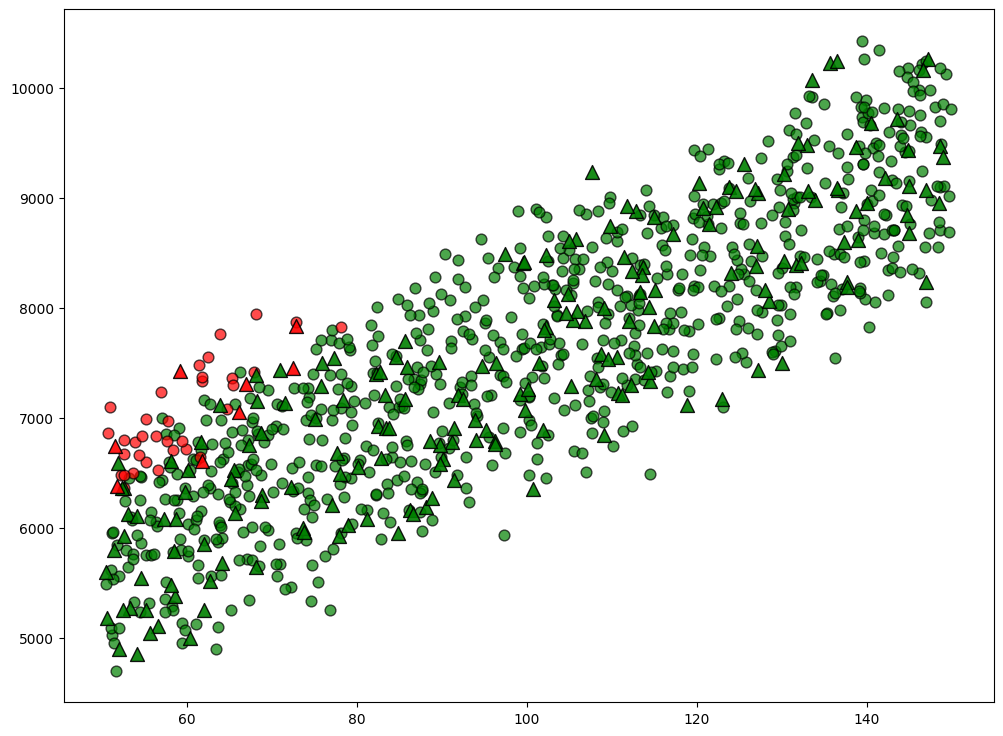

In [19]:
fig, ax = plt.subplots(figsize=(12, 9))

ax.scatter(x_train[y_train_predict == 0]['FLOW'], x_train[y_train_predict == 0]['POWER'],
           c='green', marker='o', edgecolors='black', s=60, alpha=0.7)
ax.scatter(x_train[y_train_predict == 1]['FLOW'], x_train[y_train_predict == 1]['POWER'],
           c='red', marker='o', edgecolors='black', s=60, alpha=0.7)

ax.scatter(x_test[y_test_predict == 0]['FLOW'], x_test[y_test_predict == 0]['POWER'],
           c='green', marker='^', edgecolors='black', s=100, alpha=0.9)
ax.scatter(x_test[y_test_predict == 1]['FLOW'], x_test[y_test_predict == 1]['POWER'],
           c='red', marker='^', edgecolors='black', s=100, alpha=0.9)

Модель явно переобучена - класс выставляется точечно, далеко от общей группы

## 8.


### 8.1. Постройте модель машинного обучения вида k-ближайших соседей (KNeighborsClassifier из sklearn.neighbors). Подберите оптимальное количество соседей.


In [27]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

### 8.2. По тестовой выборке оцените качество классификации теми же метриками (матрица ошибок, точность, полнота и др.).


In [28]:
y_pred = knn.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Точность модели knn: {accuracy:.4f}")
print(f"Полнота модели knn: {recall:.4f}")
print(f"Точность предсказания модели knn: {precision:.4f}")
print(f"F1-мера модели knn: {f1:.4f}")
print("Матрица ошибок модели knn:")
print(*confusion, sep="\n")

Точность модели knn: 0.9250
Полнота модели knn: 0.2941
Точность предсказания модели knn: 0.6250
F1-мера модели knn: 0.4000
Матрица ошибок модели knn:
[180   3]
[12  5]


### 8.3. Постройте график результатов классификации для метода KNN.



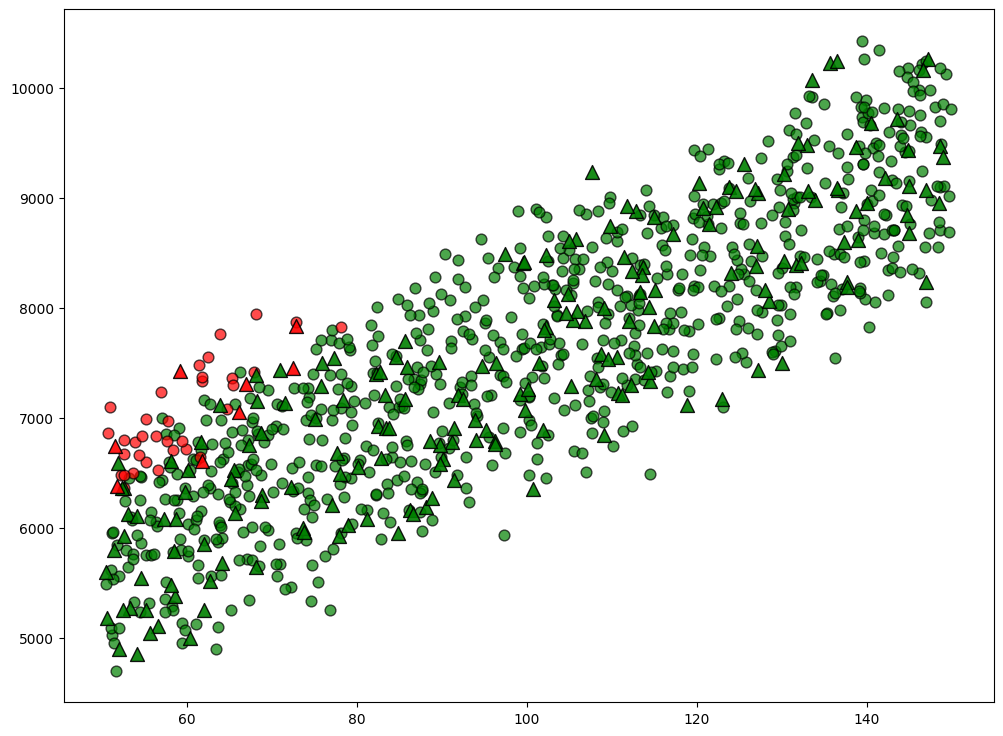

In [29]:
fig, ax = plt.subplots(figsize=(12, 9))

ax.scatter(x_train[y_train_predict == 0]['FLOW'], x_train[y_train_predict == 0]['POWER'],
           c='green', marker='o', edgecolors='black', s=60, alpha=0.7)
ax.scatter(x_train[y_train_predict == 1]['FLOW'], x_train[y_train_predict == 1]['POWER'],
           c='red', marker='o', edgecolors='black', s=60, alpha=0.7)

ax.scatter(x_test[y_test_predict == 0]['FLOW'], x_test[y_test_predict == 0]['POWER'],
           c='green', marker='^', edgecolors='black', s=100, alpha=0.9)
ax.scatter(x_test[y_test_predict == 1]['FLOW'], x_test[y_test_predict == 1]['POWER'],
           c='red', marker='^', edgecolors='black', s=100, alpha=0.9)

У модели слишком много параметров - точность понизилась.

## 9. Представьте в виде таблицы сравнительную характеристику результатов работы двух методов на ваших двух признаках. Какой алгоритм справился лучше и почему?
|Метрика\Метод| LDA | kNN|
|-|-|-|
|Accuracy|0.935|0.925|
|precision|0.75|0.625|
|recall|0.3529|0.2941|
|f1|0.48|0.4|

Все метрики выше у LDA


## Сравните метрики качества моделей, обученных на 2 признаках, с моделями, обученными на всех признаках. Сделайте выводы о том, повысилась ли точность предсказания опасности помпажа и не возникло ли переобучения

|Метрика\Метод| LDA | kNN|LDA по всем параметрам | kNN по всем параметрам|
|-|-|-|-|-|
|Accuracy|0.925|0.945|0.935|0.925|
|precision|0.75|1|0.75|0.625|
|recall|0.1765|0.3529|0.3529|0.2941|
|f1|0.2857|0.5217|0.48|0.4|

самым точным является kNN по двум параметрам - на большем количестве параметров возникает переобучение

# Часть 3. Деревья решений



## Постройте модель случайного леса (RandomForestClassifier). Опирайтесь на документацию.


In [22]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
y_pred_rf = rfc.predict(x_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
confusion_rf = confusion_matrix(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Точность модели Random Forest: {accuracy_rf:.4f}")
print(f"Полнота модели Random Forest: {recall_rf:.4f}")
print(f"Точность предсказания модели Random Forest: {precision_rf:.4f}")
print(f"F1-мера модели Random Forest: {f1_rf:.4f}")
print("Матрица ошибок модели Random Forest:")
print(*confusion_rf, sep="\n")

Точность модели Random Forest: 1.0000
Полнота модели Random Forest: 1.0000
Точность предсказания модели Random Forest: 1.0000
F1-мера модели Random Forest: 1.0000
Матрица ошибок модели Random Forest:
[183   0]
[ 0 17]


## Выведите и визуализируйте график важности признаков (feature_importances_). Сравните его с вашими выводами из матрицы корреляций.


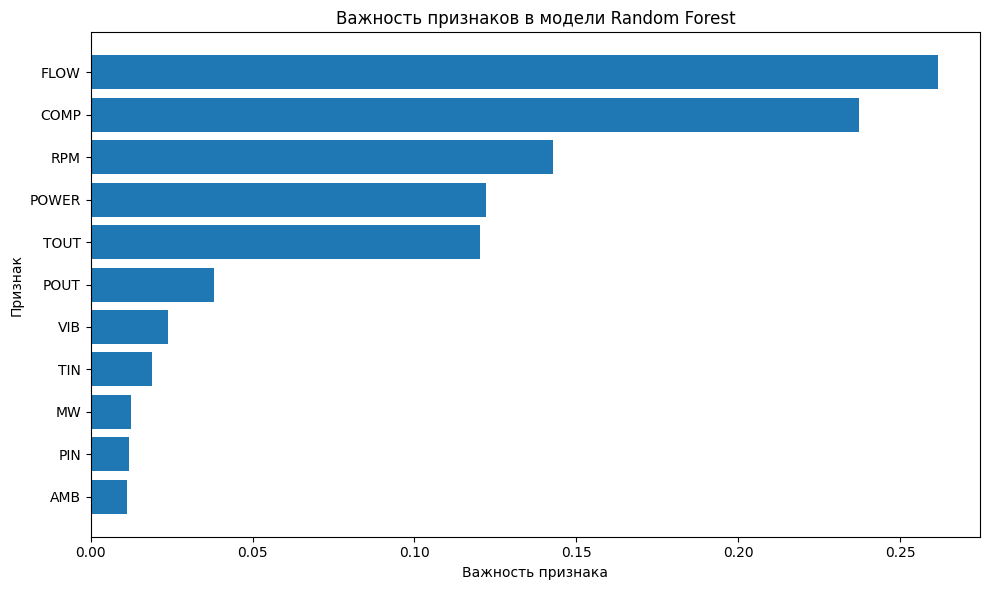


Топ-5 наиболее важных признаков:
   feature  importance
0     FLOW    0.261576
9     COMP    0.237265
5      RPM    0.142639
10   POWER    0.121966
4     TOUT    0.120135


In [24]:
feature_importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': rfc.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.title('Важность признаков в модели Random Forest')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

print("\nТоп-5 наиболее важных признаков:")
print(feature_importance.head())

In [25]:
correlations = df.corr()['STATE'].drop('STATE').abs().sort_values(ascending=False)
print("\nКорреляция признаков с целевой переменной STATE:")
print(correlations)



Корреляция признаков с целевой переменной STATE:
FLOW     0.395018
COMP     0.321975
TOUT     0.287181
RPM      0.269647
POUT     0.233298
VIB      0.173660
POWER    0.173484
AMB      0.052481
MW       0.027840
TIN      0.021981
PIN      0.016164
Name: STATE, dtype: float64


В целом главные признаки совпадают, но RFC учитывает нелинейные признаки.